In [1]:
#CH.SC.U4CSE24015 - Deepak Bharathwaj S

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv('11_Principal_Component_Analysis_Dataset_Exercise_1.csv')
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (200, 17)


,square_footage,bedrooms,baths,floors,garage,fireplace,central_heating,laundry_hookups,number_doors,front_yard,back_yard,transit_accessible,hardwood_floors,city_center,supermarket_closest_miles,school_closest_miles,Unsold_6_Months
0,883,2,1,1,0,0,1,1,3,0.78,0.52,1.00,0.49,7.17,3.14,1.97,0
1,1146,2,1,1,0,0,0,1,3,0.62,0.27,0.94,0.46,7.14,3.68,2.88,0
2,3233,4,3,2,2,1,1,2,6,0.54,0.89,0.00,0.43,0.91,0.10,0.64,0
3,1409,2,1,1,1,0,0,1,3,0.42,0.29,0.80,0.06,4.36,2.14,1.46,0
4,1307,2,1,1,0,0,1,1,3,0.64,0.72,0.65,0.46,4.41,1.19,1.25,0


In [4]:
target = data['Unsold_6_Months']
features = data.drop('Unsold_6_Months', axis=1)

sc = StandardScaler()
scaled_data = sc.fit_transform(features)

In [5]:
pca = PCA()
scores = pca.fit_transform(scaled_data)

explained = pd.DataFrame({
    'Explained Variance %': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative %': (pca.explained_variance_ratio_.cumsum() * 100).round(2),
}, index=[f'PC{i}' for i in range(1, len(features.columns) + 1)])
print(explained)

      Explained Variance %  Cumulative %
PC1                  52.40         52.40
PC2                  15.52         67.92
PC3                   8.14         76.06
PC4                   4.07         80.13
PC5                   3.82         83.95
PC6                   3.49         87.44
PC7                   2.79         90.22
PC8                   1.99         92.21
PC9                   1.68         93.89
PC10                  1.65         95.54
PC11                  1.26         96.80
PC12                  0.94         97.74
PC13                  0.81         98.55
PC14                  0.61         99.16
PC15                  0.53         99.69
PC16                  0.31        100.00


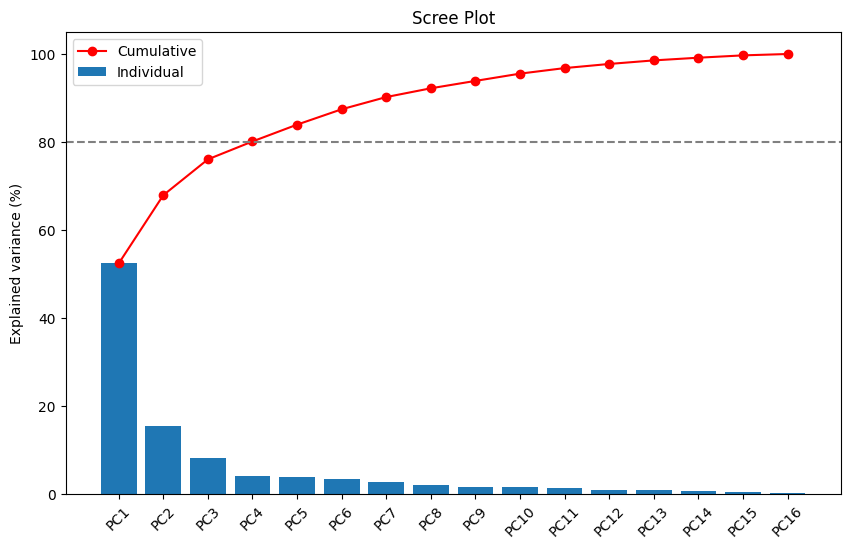

4 components explain at least 80% of the variance


In [6]:
plt.figure(figsize=(10, 6))
plt.bar(explained.index, explained['Explained Variance %'], label='Individual')
plt.plot(explained.index, explained['Cumulative %'], 'ro-', label='Cumulative')
plt.axhline(80, color='grey', linestyle='--')
plt.ylabel('Explained variance (%)')
plt.title('Scree Plot')
plt.xticks(rotation=45)
plt.legend()
plt.show()

n_pc = int((explained['Cumulative %'] < 80).sum()) + 1
print(f"{n_pc} components explain at least 80% of the variance")

In [7]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(scaled_data)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=features.columns
)

print("\nPCA Loading Matrix:")
print(loadings)

print("\nMost Influential Variables per Component:")
for pc in loadings.columns:
    variable = loadings[pc].abs().idxmax()
    value = loadings.loc[variable, pc]
    print(f"{pc}: {variable} (Loading = {value:.3f})")


PCA Loading Matrix:
                                PC1       PC2       PC3
square_footage             0.326581 -0.039691  0.183996
bedrooms                   0.312870 -0.032943  0.152170
baths                      0.293216 -0.025593  0.020234
floors                     0.187745 -0.080898  0.416527
garage                     0.286959  0.105418 -0.027310
fireplace                  0.197054  0.231611 -0.132261
central_heating            0.162990  0.302523 -0.399685
laundry_hookups            0.226917  0.130393  0.030284
number_doors               0.314939 -0.041831  0.209746
front_yard                 0.259806  0.272245 -0.065150
back_yard                  0.291588  0.186495 -0.031435
transit_accessible        -0.287113  0.190568 -0.221611
hardwood_floors            0.159153  0.380813 -0.356173
city_center               -0.267793  0.354706  0.082476
supermarket_closest_miles -0.159643  0.442096  0.410028
school_closest_miles      -0.135383  0.451236  0.435959

Most Influential Variables

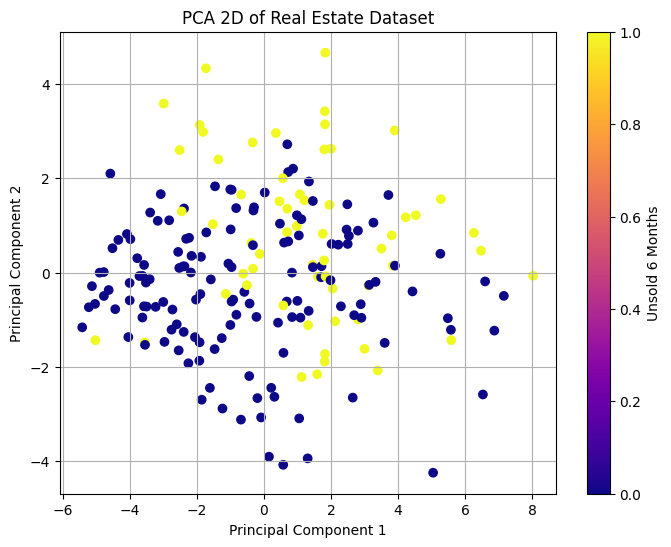

In [8]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=target, cmap='plasma')
plt.title("PCA 2D of Real Estate Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label='Unsold 6 Months')
plt.grid(True)
plt.show()

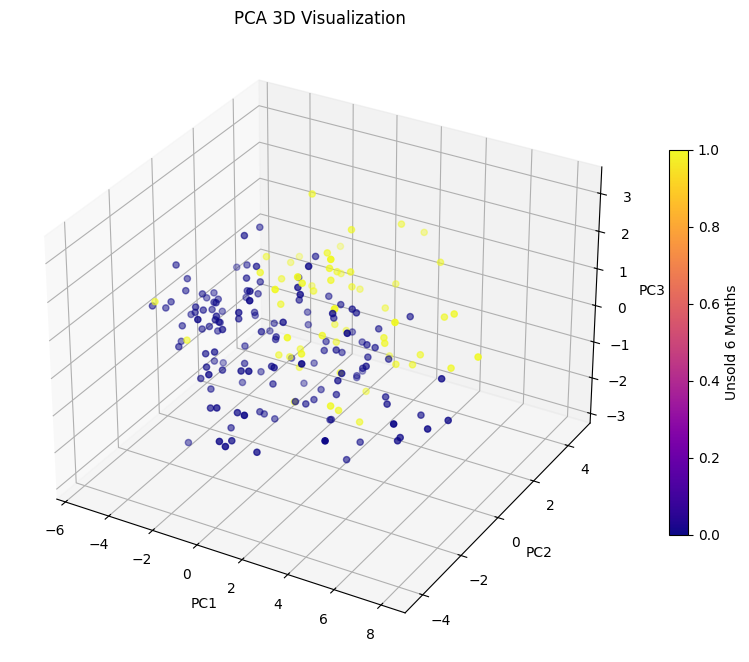

In [9]:
fig = plt.figure(figsize=(10,10))
axis = fig.add_subplot(111, projection='3d')
scatter3d = axis.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=target, cmap='plasma')
axis.set_xlabel('PC1', fontsize=10)
axis.set_ylabel('PC2', fontsize=10)
axis.set_zlabel('PC3', fontsize=10)
plt.title("PCA 3D Visualization")
plt.colorbar(scatter3d, label='Unsold 6 Months', shrink=0.5)
plt.show()